<a href="https://colab.research.google.com/github/Anagh19/Complex-Systems-Project/blob/Add-geojson-network/CS7065_DOI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
  import mesa
except:
  !pip install mesa --quiet
  import mesa

try:
  import networkx as nx
except:
  !pip install networkx --quiet
  import networkx as nx

import numpy as np
import matplotlib.pyplot as plt
import math
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 9.0 MB/s eta 0:00:00


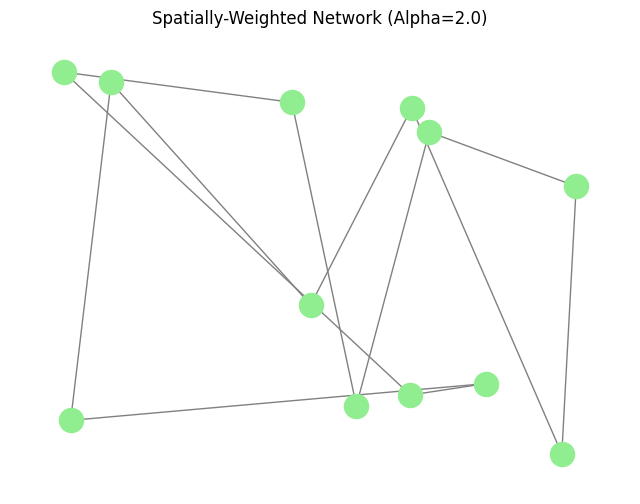

In [2]:


def spatial_watts_strogatz(n, k, p, alpha=2.0):
    """
    Generates a geographically-weighted small-world graph.
    n: number of nodes
    k: initial local connections per node
    p: rewiring probability
    alpha: spatial decay parameter (higher = stricter geographical boundaries)
    """
    # 1. Start with a perfect, un-rewired ring lattice (p=0)
    G = nx.watts_strogatz_graph(n, k, 0)

    # 2. Assign random geographical coordinates (x, y) from 0 to 100
    for node in G.nodes():
        G.nodes[node]['pos'] = (random.uniform(0, 100), random.uniform(0, 100))

    nodes = list(G.nodes())

    # 3. The Rewiring Phase
    for u, v in list(G.edges()):
        if random.random() < p:
            # The edge is selected for rewiring; remove the old local connection
            G.remove_edge(u, v)

            candidates = []
            probabilities = []
            x1, y1 = G.nodes[u]['pos']

            # Going through all the nodes in the graph other than the ones we are connected to or our own node
            for target in nodes:
                if target == u or G.has_edge(u, target):
                    continue # Skip ourselves and nodes we are already connected to
                # Find distance between this node and our current node
                x2, y2 = G.nodes[target]['pos']
                # Euclidean distance
                distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

                # Inverse-distance weighting (adding 0.001 prevents division by zero)
                weight = 1.0 / (distance**alpha + 0.001)

                candidates.append(target)
                probabilities.append(weight)

            # Normalize the weights so they sum to 1.0 (creating a valid probability distribution)
            prob_sum = sum(probabilities)
            if prob_sum > 0:
                probabilities = [w / prob_sum for w in probabilities]

                # Choose the new target using our spatial probability distribution
                new_v = np.random.choice(candidates, p=probabilities)
                G.add_edge(u, new_v)

    return G

# --- Test and Visualize ---
n_nodes = 12
k_neighbors = 2
rewire_prob = 0.3
decay_factor = 2.0 # Try changing this to 0.0 to see the Orr et al. baseline!

# Generate our custom graph
custom_G = spatial_watts_strogatz(n_nodes, k_neighbors, rewire_prob, alpha=decay_factor)

# Extract positions for plotting
positions = nx.get_node_attributes(custom_G, 'pos')

# Plotting
plt.figure(figsize=(8, 6))
plt.title(f"Spatially-Weighted Network (Alpha={decay_factor})")
nx.draw(custom_G, positions, node_color='lightgreen', node_size=300, edge_color='gray')
plt.show()